# Procesamiento documental y preselección temática

Este notebook describe la transición desde las **extracciones técnicamente válidas** obtenidas en la fase anterior hasta el conjunto de documentos **temáticamente preseleccionados** que será evaluado posteriormente mediante clasificación contextual.

El análisis se organiza alrededor de una única unidad documental: la combinación `normalized_url + archive_year`. A partir de las 390.719 extracciones válidas se reconstruye el cuerpo consolidado de **372.065 documentos únicos** y, desde ese punto, todos los indicadores de preselección utilizan ese mismo universo como denominador.

La preselección no constituye todavía el corpus final de casos de violencia machista. Su finalidad es reducir el universo documental con criterios de recuperación relativamente amplios, conservando los documentos que presentan señales léxicas o temáticas suficientes para pasar a la etapa contextual.


## 1. Configuración


In [ ]:
from pathlib import Path

import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}",
)

In [ ]:
def find_repo_root():
    here = Path.cwd().resolve()

    for candidate in [here, *here.parents]:
        if (
            (candidate / "src").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    raise RuntimeError(
        "No se pudo localizar la raíz del repositorio. "
        "Ejecuta el notebook dentro de "
        "tfm-media-violence-analysis."
    )


ROOT = find_repo_root()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


RUNS_DIR = ROOT / "data" / "runs"

OUTPUT_DIR = (
    ROOT
    / "outputs"
    / "reports"
    / "preselection"
)

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for directory in [
    OUTPUT_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


START_YEAR = 2015
END_YEAR = 2025

In [ ]:
from src.visualization.palette import COLORS


SOURCE_LABELS = {
    "clarin_arg": "Clarín",
    "lanacion": "La Nación",
    "pagina12": "Página/12",
    "milenio": "Milenio",
    "eluniversal_mx": "El Universal",
    "jornada": "La Jornada",
}

SOURCE_COUNTRY = {
    "clarin_arg": "Argentina",
    "lanacion": "Argentina",
    "pagina12": "Argentina",
    "milenio": "México",
    "eluniversal_mx": "México",
    "jornada": "México",
}

SOURCE_ORDER = {
    "Argentina": [
        "Clarín",
        "La Nación",
        "Página/12",
    ],
    "México": [
        "Milenio",
        "El Universal",
        "La Jornada",
    ],
}

ALL_NEWSPAPERS = (
    SOURCE_ORDER["Argentina"]
    + SOURCE_ORDER["México"]
)

SOURCE_COLORS = {
    "Argentina": [
        "#B9DFF1",
        COLORS["argentina"],
        COLORS["argentina_dark"],
    ],
    "México": [
        "#9ACBAD",
        COLORS["mexico"],
        COLORS["mexico_dark"],
    ],
}

COUNTRY_COLORS = {
    "Argentina": COLORS["argentina"],
    "México": COLORS["mexico_dark"],
}

PRESELECTION_COLOR = COLORS["violet_300"]
GRID_COLOR = COLORS["grid"]
TEXT_COLOR = COLORS["text"]

In [ ]:
def fmt_int(value):
    return f"{int(value):,}".replace(",", ".")


def safe_rate(numerator, denominator):
    if denominator == 0:
        return np.nan

    return 100 * numerator / denominator


def assert_columns(df, columns, name="DataFrame"):
    missing = [
        column
        for column in columns
        if column not in df.columns
    ]

    if missing:
        raise KeyError(
            f"{name} no contiene las columnas: {missing}"
        )


def add_source_labels(df):
    result = df.copy()

    if "newspaper" not in result.columns:
        result["newspaper"] = (
            result["source"]
            .map(SOURCE_LABELS)
            .fillna(result["source"])
        )

    if "country" not in result.columns:
        result["country"] = (
            result["source"]
            .map(SOURCE_COUNTRY)
        )

    return result


def nonempty_text_mask(df):
    if "text" not in df.columns:
        return pd.Series(
            False,
            index=df.index,
        )

    return (
        df["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )


def no_fetch_error_mask(df):
    if "fetch_error" not in df.columns:
        return pd.Series(
            True,
            index=df.index,
        )

    return (
        df["fetch_error"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    )


def save_figure(fig, filename):
    path = FIGURES_DIR / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    return path


def selection_rate_table(
    universe,
    selected,
    group_cols,
):
    evaluated = (
        universe
        .groupby(
            group_cols,
            dropna=False,
            as_index=False,
        )
        .size()
        .rename(
            columns={
                "size": "Noticias_evaluadas"
            }
        )
    )

    selected_counts = (
        selected
        .groupby(
            group_cols,
            dropna=False,
            as_index=False,
        )
        .size()
        .rename(
            columns={
                "size": "Noticias_preseleccionadas"
            }
        )
    )

    result = evaluated.merge(
        selected_counts,
        on=group_cols,
        how="left",
    )

    result[
        "Noticias_preseleccionadas"
    ] = (
        result[
            "Noticias_preseleccionadas"
        ]
        .fillna(0)
        .astype(int)
    )

    result["Tasa_preseleccion_pct"] = (
        100
        * result["Noticias_preseleccionadas"]
        / result["Noticias_evaluadas"]
    )

    result["Preseleccionadas_por_1000"] = (
        1000
        * result["Noticias_preseleccionadas"]
        / result["Noticias_evaluadas"]
    )

    return result

## 2. Reconstrucción y verificación del universo de partida

Los resultados de la preselección se encuentran en los archivos `articles_classified.parquet` generados por cada ejecución mensual. Antes de analizar las categorías temáticas se reconstruye el mismo universo documental empleado al finalizar la evaluación de la extracción.

Se conservan únicamente registros con texto no vacío y sin `fetch_error`. Posteriormente se aplica la clave documental `normalized_url + archive_year`. Esta operación no vuelve a evaluar la calidad de extracción: su objetivo es garantizar que el análisis de preselección se realiza sobre documentos únicos y no sobre múltiples capturas de una misma URL dentro del mismo año.


In [ ]:
RUN_PATTERN = re.compile(
    r"(20\d{2})_(0[1-9]|1[0-2])"
)

classified_files = sorted(
    RUNS_DIR.glob(
        "*/processed/articles_classified.parquet"
    )
)

if not classified_files:
    raise FileNotFoundError(
        "No se encontraron "
        "articles_classified.parquet "
        f"bajo {RUNS_DIR}"
    )

print(
    "Archivos encontrados:",
    len(classified_files),
)

Archivos encontrados: 132


In [ ]:
classified_parts = []

for path in classified_files:

    match = RUN_PATTERN.search(
        str(path)
    )

    if match is None:
        continue

    year = int(match.group(1))
    month = int(match.group(2))

    if not (
        START_YEAR
        <= year
        <= END_YEAR
    ):
        continue

    df = pd.read_parquet(path)

    assert_columns(
        df,
        [
            "source",
            "normalized_url",
            "text",
            "candidate_label",
            "candidate_type",
            "retrieval_bucket",
            "is_retrieval_candidate",
        ],
        str(path),
    )

    valid = (
        nonempty_text_mask(df)
        & no_fetch_error_mask(df)
    )

    tmp = (
        df.loc[valid]
        .copy()
    )

    # El año y el mes se reconstruyen desde la ejecución
    # para mantener una definición temporal homogénea.
    tmp["archive_year"] = year
    tmp["archive_month"] = month
    tmp["run_id"] = (
        f"{year:04d}_{month:02d}"
    )

    classified_parts.append(tmp)


if not classified_parts:
    raise RuntimeError(
        "No se reconstruyó ningún documento clasificado."
    )


valid_classified = pd.concat(
    classified_parts,
    ignore_index=True,
    sort=False,
)

valid_classified = add_source_labels(
    valid_classified
)

print(
    "Extracciones técnicamente válidas:",
    f"{len(valid_classified):,}",
)

Extracciones técnicamente válidas: 390,719


In [ ]:
DOC_KEY = [
    "normalized_url",
    "archive_year",
]

assert_columns(
    valid_classified,
    DOC_KEY,
    "valid_classified",
)

key_complete = (
    valid_classified[DOC_KEY]
    .notna()
    .all(axis=1)
    & valid_classified[
        "normalized_url"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

if not key_complete.all():
    raise ValueError(
        "Existen extracciones válidas "
        "sin clave documental completa."
    )


duplicate_mask = (
    valid_classified
    .duplicated(
        subset=DOC_KEY,
        keep="first",
    )
)

n_valid_extractions = len(
    valid_classified
)

n_duplicates = int(
    duplicate_mask.sum()
)

documents = (
    valid_classified.loc[
        ~duplicate_mask
    ]
    .copy()
    .reset_index(drop=True)
)

n_documents = len(documents)


# Controles de continuidad con el Notebook 1.
EXPECTED_VALID = 390_719
EXPECTED_DUPLICATES = 18_654
EXPECTED_DOCUMENTS = 372_065

assert n_valid_extractions == EXPECTED_VALID, (
    "El número de extracciones válidas no coincide "
    f"con el esperado: {n_valid_extractions:,} != "
    f"{EXPECTED_VALID:,}."
)

assert n_duplicates == EXPECTED_DUPLICATES, (
    "El número de duplicados no coincide "
    f"con el esperado: {n_duplicates:,} != "
    f"{EXPECTED_DUPLICATES:,}."
)

assert n_documents == EXPECTED_DOCUMENTS, (
    "El cuerpo consolidado no coincide "
    f"con el esperado: {n_documents:,} != "
    f"{EXPECTED_DOCUMENTS:,}."
)

assert not documents.duplicated(
    subset=DOC_KEY
).any()


print(
    "Extracciones válidas:",
    f"{n_valid_extractions:,}",
)

print(
    "Duplicados eliminados:",
    f"{n_duplicates:,}",
)

print(
    "Documentos únicos evaluables:",
    f"{n_documents:,}",
)

Extracciones válidas: 390,719
Duplicados eliminados: 18,654
Documentos únicos evaluables: 372,065


In [ ]:
input_summary = pd.DataFrame({
    "Indicador": [
        "Extracciones técnicamente válidas",
        "Registros eliminados por deduplicación",
        "Documentos únicos evaluables",
    ],
    "Documentos": [
        n_valid_extractions,
        n_duplicates,
        n_documents,
    ],
    "Porcentaje_sobre_validas": [
        100.0,
        safe_rate(
            n_duplicates,
            n_valid_extractions,
        ),
        safe_rate(
            n_documents,
            n_valid_extractions,
        ),
    ],
})

display(
    input_summary.round(2)
)

input_summary.to_csv(
    TABLES_DIR / "01_universo_documental.csv",
    index=False,
)

,Indicador,Documentos,Porcentaje_sobre_validas
0,Extracciones técnicamente válidas,390719,100.00
1,Registros eliminados por deduplicación,18654,4.77
2,Documentos únicos evaluables,372065,95.23


A partir de este punto, **372.065 documentos únicos** constituyen el denominador del análisis. Las tasas que aparecen en las secciones siguientes se calculan sobre este universo o sobre sus correspondientes subconjuntos por país, periódico y año.

La deduplicación elimina 18.654 registros repetidos respecto de las 390.719 extracciones válidas. No se interpreta esta reducción como pérdida temática: representa la consolidación de múltiples observaciones técnicas de una misma unidad documental.


## 3. Definición de la preselección temática

La preselección es una etapa de **recuperación**, no una decisión final sobre si una noticia constituye un caso de violencia machista. El pipeline combina señales asociadas a casos concretos, señales temáticas más amplias y evidencia de proximidad entre términos. Estas señales se resumen en puntuaciones y etiquetas intermedias.

La variable `is_retrieval_candidate` representa la decisión final de esta etapa: un documento con valor verdadero pasa a la clasificación contextual posterior. Las variables `candidate_type` y `retrieval_bucket` permiten describir por qué vía fue recuperado.

En consecuencia, en este notebook se analiza la **sensibilidad y composición de la preselección**. Las categorías contextuales y la construcción del corpus final se reservan para el notebook siguiente.


In [ ]:
required_preselection_columns = [
    "case_score",
    "topic_score",
    "relevance_score",
    "candidate_label",
    "candidate_type",
    "retrieval_bucket",
    "is_case_candidate",
    "is_topic_candidate",
    "is_retrieval_candidate",
]

assert_columns(
    documents,
    required_preselection_columns,
    "documents",
)

preselection_variables = pd.DataFrame({
    "Variable": [
        "case_score",
        "topic_score",
        "relevance_score",
        "candidate_label",
        "candidate_type",
        "retrieval_bucket",
        "is_case_candidate",
        "is_topic_candidate",
        "is_retrieval_candidate",
    ],
    "Función": [
        "Intensidad de señales asociadas a casos",
        "Intensidad de señales temáticas",
        "Puntuación combinada de relevancia",
        "Etiqueta resultante de las reglas de candidatura",
        "Tipo de candidato recuperado",
        "Vía o grupo de recuperación",
        "Indicador de candidatura por señales de caso",
        "Indicador de candidatura por señales temáticas",
        "Indicador final de entrada a la preselección",
    ],
})

display(preselection_variables)

,Variable,Función
0,case_score,Intensidad de señales asociadas a casos
1,topic_score,Intensidad de señales temáticas
2,relevance_score,Puntuación combinada de relevancia
3,candidate_label,Etiqueta resultante de las reglas de candidatura
4,candidate_type,Tipo de candidato recuperado
5,retrieval_bucket,Vía o grupo de recuperación
6,is_case_candidate,Indicador de candidatura por señales de caso
7,is_topic_candidate,Indicador de candidatura por señales temáticas
8,is_retrieval_candidate,Indicador final de entrada a la preselección


In [ ]:
if documents[
    "is_retrieval_candidate"
].isna().any():
    raise ValueError(
        "is_retrieval_candidate contiene valores nulos."
    )

documents["preselected"] = (
    documents[
        "is_retrieval_candidate"
    ]
    .astype(bool)
)

preselected_cases = (
    documents.loc[
        documents["preselected"]
    ]
    .copy()
)

n_preselected = len(preselected_cases)
n_not_preselected = (
    n_documents
    - n_preselected
)

assert (
    n_preselected
    + n_not_preselected
    == n_documents
)

## 4. Resultado global de la preselección


In [ ]:
preselection_global = pd.DataFrame({
    "Grupo": [
        "Preseleccionadas",
        "No preseleccionadas",
    ],
    "Noticias": [
        n_preselected,
        n_not_preselected,
    ],
})

preselection_global["Porcentaje"] = (
    100
    * preselection_global["Noticias"]
    / n_documents
)

display(
    preselection_global.round(2)
)

print(
    "Universo documental:",
    f"{n_documents:,}",
)

print(
    "Noticias preseleccionadas:",
    f"{n_preselected:,}",
)

print(
    "Tasa global de preselección:",
    f"{safe_rate(n_preselected, n_documents):.2f}%",
)

print(
    "Preseleccionadas por 1.000 evaluadas:",
    f"{1000 * n_preselected / n_documents:.2f}",
)

preselection_global.to_csv(
    TABLES_DIR / "02_resultado_global_preseleccion.csv",
    index=False,
)

,Grupo,Noticias,Porcentaje
0,Preseleccionadas,7729,2.08
1,No preseleccionadas,364336,97.92


Universo documental: 372,065
Noticias preseleccionadas: 7,729
Tasa global de preselección: 2.08%
Preseleccionadas por 1.000 evaluadas: 20.77


El porcentaje anterior expresa la reducción producida por las reglas de recuperación sobre el cuerpo consolidado. No debe interpretarse como prevalencia de violencia machista en la prensa: incluye documentos recuperados con distintos niveles y tipos de señal que todavía deben ser evaluados contextualmente.


### 4.1 Composición de las vías de recuperación


In [ ]:
retrieval_summary = (
    preselected_cases[
        "retrieval_bucket"
    ]
    .fillna("missing")
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Categoría"
    )
    .reset_index(
        name="Noticias"
    )
)

retrieval_summary["Porcentaje"] = (
    100
    * retrieval_summary["Noticias"]
    / n_preselected
)

display(
    retrieval_summary
    .sort_values(
        "Noticias",
        ascending=False,
    )
    .round(2)
)

retrieval_summary.to_csv(
    TABLES_DIR / "03_composicion_retrieval_bucket.csv",
    index=False,
)

,Categoría,Noticias,Porcentaje
0,case_strong,3601,46.59
1,topic_gender_violence,2958,38.27
2,case_review_possible_violence,781,10.10
3,case_review_female_death,234,3.03
4,case_review_female_disappearance,155,2.01


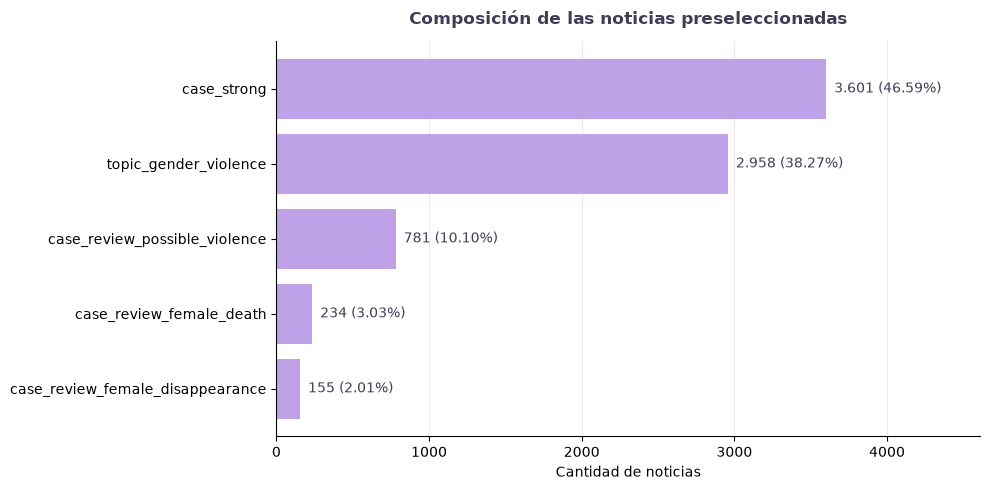

In [ ]:
plot_data = (
    retrieval_summary
    .sort_values("Noticias")
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

bars = ax.barh(
    plot_data["Categoría"],
    plot_data["Noticias"],
    color=PRESELECTION_COLOR,
)

for bar, (_, row) in zip(
    bars,
    plot_data.iterrows(),
):
    ax.text(
        bar.get_width(),
        bar.get_y()
        + bar.get_height() / 2,
        (
            f"  {fmt_int(row['Noticias'])} "
            f"({row['Porcentaje']:.2f}%)"
        ),
        va="center",
        fontsize=10,
        color=TEXT_COLOR,
    )

ax.set_title(
    "Composición de las noticias preseleccionadas",
    fontsize=12,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_xlabel(
    "Cantidad de noticias"
)
ax.set_ylabel("")

ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.8,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

if len(plot_data):
    ax.set_xlim(
        0,
        plot_data["Noticias"].max() * 1.28,
    )

plt.tight_layout()

save_figure(
    fig,
    "01_composicion_preseleccion.png",
)

plt.show()

### 4.2 Relación entre `retrieval_bucket` y `candidate_type`

Las dos variables describen dimensiones relacionadas pero no necesariamente equivalentes del mecanismo de recuperación. La tabla cruzada permite comprobar si aportan información distinta antes de decidir qué categorías deben conservarse en la presentación de resultados.


In [ ]:
candidate_type_summary = (
    preselected_cases[
        "candidate_type"
    ]
    .fillna("missing")
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "candidate_type"
    )
    .reset_index(
        name="Noticias"
    )
)

candidate_type_summary["Porcentaje"] = (
    100
    * candidate_type_summary["Noticias"]
    / n_preselected
)

candidate_cross = pd.crosstab(
    preselected_cases[
        "retrieval_bucket"
    ].fillna("missing"),
    preselected_cases[
        "candidate_type"
    ].fillna("missing"),
    margins=True,
)

display(
    candidate_type_summary.round(2)
)

display(candidate_cross)

,candidate_type,Noticias,Porcentaje
0,case_and_topic,3101,40.12
1,topic,2958,38.27
2,case,1670,21.61


candidate_type,case,case_and_topic,topic,All
retrieval_bucket,,,,
case_review_female_death,233,1,0,234
case_review_female_disappearance,154,1,0,155
case_review_possible_violence,719,62,0,781
case_strong,564,3037,0,3601
topic_gender_violence,0,0,2958,2958
All,1670,3101,2958,7729


## 5. Variación de la preselección por país y periódico

Los conteos absolutos no son directamente comparables entre fuentes porque el número de documentos disponibles varía entre países y periódicos. Por ello se presentan tasas calculadas sobre el número de documentos únicos evaluados en cada grupo.

Para la comparación agregada por país se utiliza el porcentaje. Para la comparación entre periódicos se expresa la misma tasa por **1.000 documentos evaluados**, una escala más legible cuando la proporción de documentos recuperados es pequeña.


### 5.1 Tasa de preselección por país


In [ ]:
preselection_country = (
    selection_rate_table(
        documents,
        preselected_cases,
        ["country"],
    )
)

display(
    preselection_country.round(2)
)

preselection_country.to_csv(
    TABLES_DIR / "04_preseleccion_pais.csv",
    index=False,
)

,country,Noticias_evaluadas,Noticias_preseleccionadas,Tasa_preseleccion_pct,Preseleccionadas_por_1000
0,Argentina,166061,3115,1.88,18.76
1,México,206004,4614,2.24,22.40


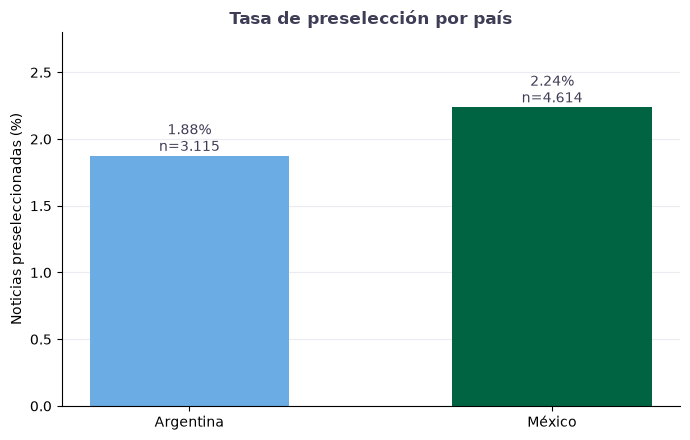

In [ ]:
fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

country_colors = [
    COUNTRY_COLORS.get(
        country,
        PRESELECTION_COLOR,
    )
    for country
    in preselection_country["country"]
]

bars = ax.bar(
    preselection_country["country"],
    preselection_country[
        "Tasa_preseleccion_pct"
    ],
    color=country_colors,
    width=0.55,
)

for bar, (_, row) in zip(
    bars,
    preselection_country.iterrows(),
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        (
            f"{row['Tasa_preseleccion_pct']:.2f}%\n"
            f"n={fmt_int(row['Noticias_preseleccionadas'])}"
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        color=TEXT_COLOR,
    )

ax.set_title(
    "Tasa de preselección por país",
    fontweight="bold",
    color=TEXT_COLOR,
)

ax.set_ylabel(
    "Noticias preseleccionadas (%)"
)
ax.set_xlabel("")

ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.8,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

max_rate = (
    preselection_country[
        "Tasa_preseleccion_pct"
    ].max()
)

ax.set_ylim(
    0,
    max_rate * 1.25
    if max_rate > 0
    else 1,
)

plt.tight_layout()

save_figure(
    fig,
    "02_tasa_preseleccion_pais.png",
)

plt.show()

### 5.2 Tasa de preselección por periódico


In [ ]:
preselection_newspaper = (
    selection_rate_table(
        documents,
        preselected_cases,
        [
            "country",
            "newspaper",
        ],
    )
)

display(
    preselection_newspaper
    .sort_values(
        [
            "country",
            "newspaper",
        ]
    )
    .round(2)
)

preselection_newspaper.to_csv(
    TABLES_DIR / "05_preseleccion_periodico.csv",
    index=False,
)

,country,newspaper,Noticias_evaluadas,Noticias_preseleccionadas,Tasa_preseleccion_pct,Preseleccionadas_por_1000
0,Argentina,Clarín,66157,1509,2.28,22.81
1,Argentina,La Nación,84153,1190,1.41,14.14
2,Argentina,Página/12,15751,416,2.64,26.41
3,México,El Universal,4446,29,0.65,6.52
4,México,La Jornada,65466,1710,2.61,26.12
5,México,Milenio,136092,2875,2.11,21.13


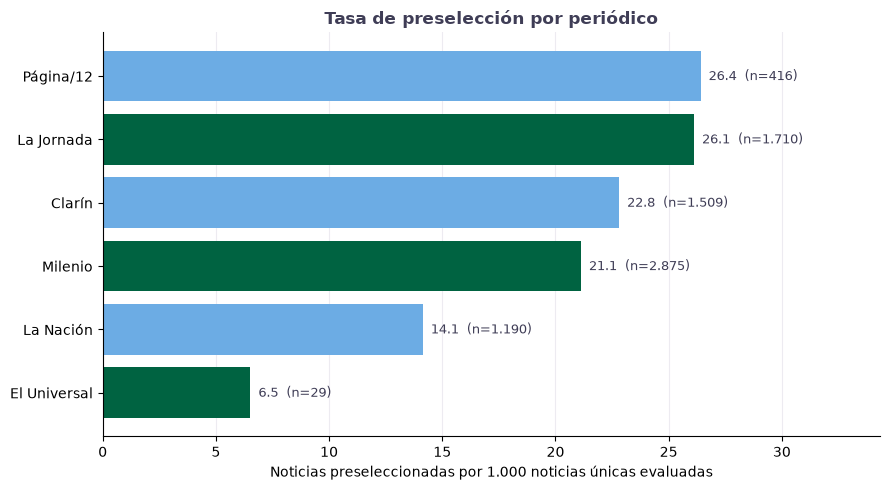

In [ ]:
plot_data = (
    preselection_newspaper
    .sort_values(
        "Preseleccionadas_por_1000"
    )
)

bar_colors = [
    COUNTRY_COLORS.get(
        country,
        PRESELECTION_COLOR,
    )
    for country
    in plot_data["country"]
]

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    plot_data["newspaper"],
    plot_data[
        "Preseleccionadas_por_1000"
    ],
    color=bar_colors,
)

for bar, (_, row) in zip(
    bars,
    plot_data.iterrows(),
):
    ax.text(
        bar.get_width(),
        bar.get_y()
        + bar.get_height() / 2,
        (
            f"  {row['Preseleccionadas_por_1000']:.1f}"
            f"  (n={fmt_int(row['Noticias_preseleccionadas'])})"
        ),
        va="center",
        fontsize=9,
        color=TEXT_COLOR,
    )

ax.set_title(
    "Tasa de preselección por periódico",
    fontweight="bold",
    color=TEXT_COLOR,
)

ax.set_xlabel(
    "Noticias preseleccionadas por 1.000 noticias únicas evaluadas"
)
ax.set_ylabel("")

ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.8,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

max_rate = (
    plot_data[
        "Preseleccionadas_por_1000"
    ].max()
)

ax.set_xlim(
    0,
    max_rate * 1.30
    if max_rate > 0
    else 1,
)

plt.tight_layout()

save_figure(
    fig,
    "03_tasa_preseleccion_periodico.png",
)

plt.show()

Las diferencias entre medios deben interpretarse como diferencias en la **tasa de recuperación del procedimiento de preselección**, no directamente como diferencias en la incidencia real del fenómeno. La disponibilidad documental, las convenciones editoriales y el vocabulario utilizado por cada medio pueden afectar estas tasas.


## 6. Evolución temporal de la preselección


La comparación temporal también se normaliza por el número de documentos evaluados. De este modo, un año con mayor disponibilidad de noticias no produce automáticamente una tasa de preselección mayor.

Se utiliza la escala de documentos preseleccionados por 1.000 evaluados para mantener la misma unidad empleada en la comparación entre periódicos.


### 6.1 Evolución global


In [ ]:
preselection_year = (
    selection_rate_table(
        documents,
        preselected_cases,
        ["archive_year"],
    )
    .sort_values(
        "archive_year"
    )
)

display(
    preselection_year.round(2)
)

preselection_year.to_csv(
    TABLES_DIR / "06_preseleccion_anio.csv",
    index=False,
)

,archive_year,Noticias_evaluadas,Noticias_preseleccionadas,Tasa_preseleccion_pct,Preseleccionadas_por_1000
0,2015,30298,472,1.56,15.58
1,2016,37155,785,2.11,21.13
2,2017,19853,483,2.43,24.33
3,2018,14190,312,2.20,21.99
4,2019,8216,182,2.22,22.15
5,2020,9865,230,2.33,23.31
6,2021,43216,969,2.24,22.42
7,2022,47320,1247,2.64,26.35
8,2023,53603,1084,2.02,20.22
9,2024,48117,896,1.86,18.62


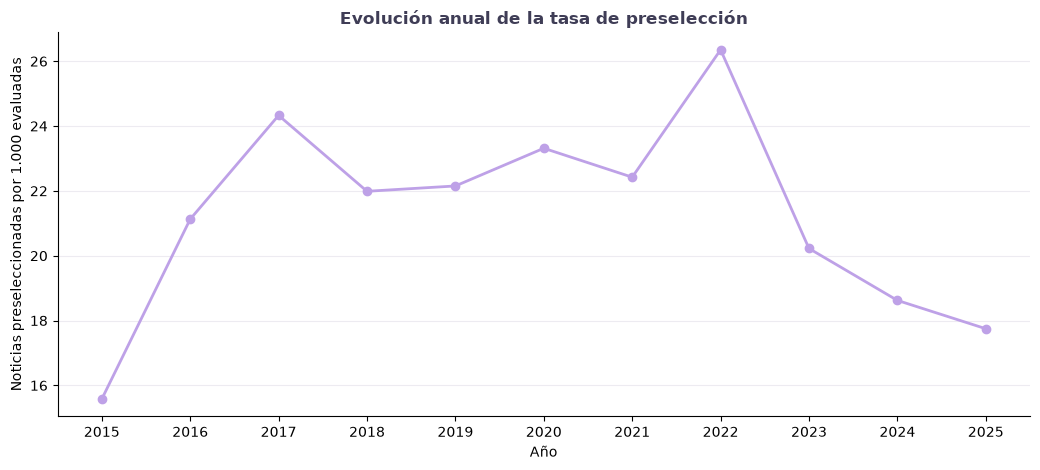

In [ ]:
fig, ax = plt.subplots(
    figsize=(10.5, 4.8)
)

ax.plot(
    preselection_year[
        "archive_year"
    ],
    preselection_year[
        "Preseleccionadas_por_1000"
    ],
    marker="o",
    linewidth=2,
    color=PRESELECTION_COLOR,
)

ax.set_title(
    "Evolución anual de la tasa de preselección",
    fontweight="bold",
    color=TEXT_COLOR,
)

ax.set_xlabel("Año")
ax.set_ylabel(
    "Noticias preseleccionadas por 1.000 evaluadas"
)

ax.set_xticks(
    range(
        START_YEAR,
        END_YEAR + 1,
    )
)

ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.8,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

save_figure(
    fig,
    "04_evolucion_preseleccion_anual.png",
)

plt.show()

### 6.2 Evolución anual por país


In [ ]:
preselection_country_year = (
    selection_rate_table(
        documents,
        preselected_cases,
        [
            "country",
            "archive_year",
        ],
    )
)

preselection_country_year = (
    preselection_country_year
    .sort_values(
        [
            "country",
            "archive_year",
        ]
    )
)

display(
    preselection_country_year.round(2)
)

,country,archive_year,Noticias_evaluadas,Noticias_preseleccionadas,Tasa_preseleccion_pct,Preseleccionadas_por_1000
0,Argentina,2015,11331,274,2.42,24.18
1,Argentina,2016,22847,565,2.47,24.73
2,Argentina,2017,7878,251,3.19,31.86
3,Argentina,2018,6493,161,2.48,24.80
4,Argentina,2019,4965,116,2.34,23.36
5,Argentina,2020,4967,86,1.73,17.31
6,Argentina,2021,6017,105,1.75,17.45
7,Argentina,2022,5679,107,1.88,18.84
8,Argentina,2023,29285,474,1.62,16.19
9,Argentina,2024,29220,455,1.56,15.57


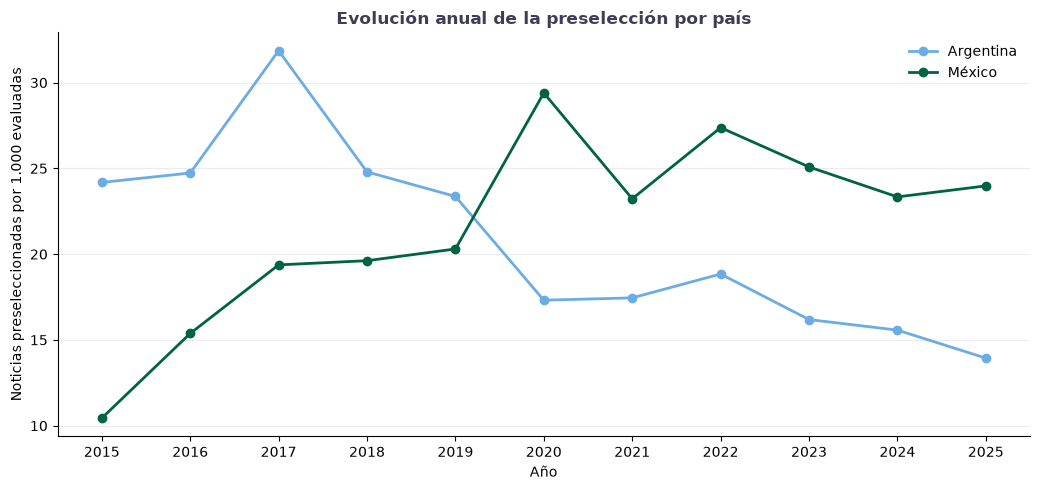

In [ ]:
fig, ax = plt.subplots(
    figsize=(10.5, 5)
)

for country in [
    "Argentina",
    "México",
]:
    subset = (
        preselection_country_year.loc[
            preselection_country_year[
                "country"
            ]
            == country
        ]
        .sort_values(
            "archive_year"
        )
    )

    ax.plot(
        subset["archive_year"],
        subset[
            "Preseleccionadas_por_1000"
        ],
        marker="o",
        linewidth=2,
        label=country,
        color=COUNTRY_COLORS[country],
    )

ax.set_title(
    "Evolución anual de la preselección por país",
    fontweight="bold",
    color=TEXT_COLOR,
)

ax.set_xlabel("Año")
ax.set_ylabel(
    "Noticias preseleccionadas por 1.000 evaluadas"
)

ax.set_xticks(
    range(
        START_YEAR,
        END_YEAR + 1,
    )
)

ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.8,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
)

plt.tight_layout()

save_figure(
    fig,
    "05_evolucion_preseleccion_pais.png",
)

plt.show()

### 6.3 Variación por periódico y año


In [ ]:
preselection_year_source = (
    selection_rate_table(
        documents.dropna(
            subset=[
                "archive_year",
                "newspaper",
            ]
        ),
        preselected_cases.dropna(
            subset=[
                "archive_year",
                "newspaper",
            ]
        ),
        [
            "country",
            "newspaper",
            "archive_year",
        ],
    )
)

preselection_heatmap = (
    preselection_year_source
    .pivot_table(
        index="newspaper",
        columns="archive_year",
        values="Preseleccionadas_por_1000",
        aggfunc="mean",
    )
    .reindex(
        index=ALL_NEWSPAPERS,
        columns=range(
            START_YEAR,
            END_YEAR + 1,
        ),
    )
)

display(
    preselection_heatmap.round(1)
)

preselection_year_source.to_csv(
    TABLES_DIR / "07_preseleccion_periodico_anio.csv",
    index=False,
)

archive_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
newspaper,,,,,,,,,,,
Clarín,25.20,20.30,31.90,24.70,25.30,18.20,18.10,19.90,25.50,13.20,22.00
La Nación,0.00,0.00,0.00,0.00,11.50,9.30,7.70,14.20,13.90,15.90,13.10
Página/12,22.40,30.90,30.00,32.80,0.00,28.60,0.00,12.20,17.20,0.00,12.40
Milenio,11.60,15.30,19.40,20.20,20.90,31.90,16.20,23.90,25.20,23.70,24.00
El Universal,6.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
La Jornada,200.00,142.90,0.00,14.70,16.60,21.90,24.60,29.00,21.60,20.40,22.10


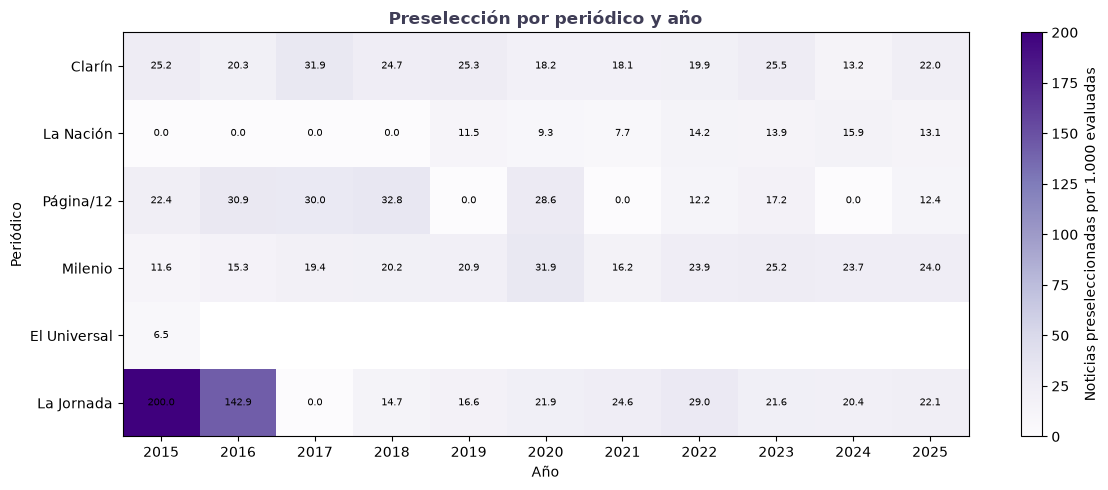

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

masked = np.ma.masked_invalid(
    preselection_heatmap
    .to_numpy(
        dtype=float
    )
)

im = ax.imshow(
    masked,
    aspect="auto",
    cmap="Purples",
)

ax.set_title(
    "Preselección por periódico y año",
    fontsize=12,
    fontweight="bold",
    color=TEXT_COLOR,
)

ax.set_xlabel("Año")
ax.set_ylabel("Periódico")

ax.set_xticks(
    np.arange(
        len(
            preselection_heatmap.columns
        )
    )
)
ax.set_xticklabels(
    preselection_heatmap.columns
)

ax.set_yticks(
    np.arange(
        len(
            preselection_heatmap.index
        )
    )
)
ax.set_yticklabels(
    preselection_heatmap.index
)

for i in range(
    len(
        preselection_heatmap.index
    )
):
    for j in range(
        len(
            preselection_heatmap.columns
        )
    ):
        value = (
            preselection_heatmap
            .iloc[i, j]
        )

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=7,
            )

cbar = fig.colorbar(
    im,
    ax=ax,
)

cbar.set_label(
    "Noticias preseleccionadas por 1.000 evaluadas"
)

fig.tight_layout()

save_figure(
    fig,
    "06_heatmap_preseleccion_periodico_anio.png",
)

plt.show()

El mapa de calor permite identificar simultáneamente variaciones temporales y diferencias entre medios. Los valores deben leerse como tasas de recuperación sobre la documentación disponible en cada combinación periódico-año. Las celdas sin información permanecen vacías y no se interpretan como una tasa igual a cero.


## 7. Controles de consistencia


Antes de cerrar la etapa se comprueba que las distintas agregaciones reproducen exactamente el universo documental y el conjunto preseleccionado. Estos controles evitan que una diferencia de denominadores entre tablas o gráficos introduzca resultados incompatibles.


In [ ]:
assert (
    preselection_global["Noticias"].sum()
    == n_documents
)

assert (
    preselection_country[
        "Noticias_evaluadas"
    ].sum()
    == n_documents
)

assert (
    preselection_country[
        "Noticias_preseleccionadas"
    ].sum()
    == n_preselected
)

assert (
    preselection_newspaper[
        "Noticias_evaluadas"
    ].sum()
    == n_documents
)

assert (
    preselection_newspaper[
        "Noticias_preseleccionadas"
    ].sum()
    == n_preselected
)

assert (
    preselection_year[
        "Noticias_evaluadas"
    ].sum()
    == n_documents
)

assert (
    preselection_year[
        "Noticias_preseleccionadas"
    ].sum()
    == n_preselected
)

assert (
    retrieval_summary["Noticias"].sum()
    == n_preselected
)

assert (
    candidate_type_summary["Noticias"].sum()
    == n_preselected
)

print("Todos los controles de consistencia se superaron.")

Todos los controles de consistencia se superaron.


## 8. Síntesis y transición a la clasificación contextual


In [ ]:
final_summary = pd.DataFrame({
    "Indicador": [
        "Extracciones técnicamente válidas",
        "Duplicados eliminados",
        "Documentos únicos evaluables",
        "Documentos preseleccionados",
        "Documentos no preseleccionados",
        "Tasa global de preselección (%)",
        "Preseleccionados por 1.000 evaluados",
    ],
    "Valor": [
        n_valid_extractions,
        n_duplicates,
        n_documents,
        n_preselected,
        n_not_preselected,
        safe_rate(
            n_preselected,
            n_documents,
        ),
        (
            1000
            * n_preselected
            / n_documents
        ),
    ],
})

display(
    final_summary.round(2)
)

final_summary.to_csv(
    TABLES_DIR / "08_sintesis_preseleccion.csv",
    index=False,
)

,Indicador,Valor
0,Extracciones técnicamente válidas,"390,719.00"
1,Duplicados eliminados,"18,654.00"
2,Documentos únicos evaluables,"372,065.00"
3,Documentos preseleccionados,"7,729.00"
4,Documentos no preseleccionados,"364,336.00"
5,Tasa global de preselección (%),2.08
6,Preseleccionados por 1.000 evaluados,20.77


La secuencia documental analizada en este notebook puede resumirse de la siguiente manera:

**390.719 extracciones técnicamente válidas → 372.065 documentos únicos evaluables → preselección temática → clasificación contextual.**

La preselección reduce el universo documental utilizando señales léxicas y temáticas, pero **no determina todavía qué documentos integrarán el corpus final de casos**. Los documentos recuperados pasan a una etapa posterior en la que se evalúa la evidencia contextual, el reconocimiento explícito de la violencia de género y otros criterios necesarios para construir el corpus analítico.

Por esta razón, las tasas presentadas aquí describen el comportamiento del **procedimiento de recuperación**. Las conclusiones sustantivas sobre la cobertura mediática de la violencia machista deben formularse posteriormente sobre el corpus final validado. El trabajo continua en el notebook 03.
